# Análise Global do Câncer — GBD 2023

## Pergunta de Pesquisa
> **Quais cânceres representam o maior desafio global entre 2013 e 2023 — considerando incidência, mortalidade, prevalência e impacto na qualidade de vida?**

## Fonte dos Dados
Global Burden of Disease Collaborative Network. *Global Burden of Disease Study 2023 (GBD 2023) Results.*
Seattle, United States: Institute for Health Metrics and Evaluation (IHME), 2024.
Disponível em: https://vizhub.healthdata.org/gbd-results/

## Estrutura do Estudo
O estudo é organizado em três blocos:

1. **Preparação dos dados** — importação, limpeza e filtragem do banco GBD 2023
2. **Análise descritiva** — quem mais adoece, quem mais morre e quem mais prevalece
3. **Análise avançada** — perfil de agressividade e evolução temporal dos cânceres


## Bloco 1 — Preparação dos Dados

### Célula 1 — Importação de Bibliotecas

Antes de qualquer análise, carregamos as bibliotecas necessárias. Cada uma tem um papel específico: **pandas** para manipular tabelas, **numpy** para cálculos numéricos, **matplotlib** e **seaborn** para os gráficos.

In [6]:
# pandas: biblioteca principal para leitura e manipulação de tabelas (DataFrames)
import pandas as pd

# numpy: suporte a operações matemáticas e vetoriais
import numpy as np

# matplotlib.pyplot: criação dos gráficos (linhas, barras, pizza, etc.)
import matplotlib.pyplot as plt

# mticker: formatação personalizada dos eixos dos gráficos
import matplotlib.ticker as mticker

# seaborn: estilos visuais mais elegantes para os gráficos do matplotlib
import seaborn as sns

# define o tema visual padrão: fundo com grade branca, paleta de 10 cores distintas
sns.set_theme(style='whitegrid', palette='tab10')

# resolução dos gráficos em 120 pontos por polegada (imagem mais nítida)
plt.rcParams['figure.dpi'] = 120

# tamanho padrão de cada figura: 12 de largura × 6 de altura (em polegadas)
plt.rcParams['figure.figsize'] = (12, 6)

# tamanho da fonte do título de cada gráfico
plt.rcParams['axes.titlesize'] = 14

# tamanho da fonte dos rótulos dos eixos X e Y
plt.rcParams['axes.labelsize'] = 11

# biblioteca para suprimir alertas que não afetam o resultado
import warnings

# oculta todos os warnings durante a execução
warnings.filterwarnings('ignore')

print('✅ Bibliotecas importadas com sucesso!')
print(f'   pandas     {pd.__version__}')                    # exibe versão do pandas
print(f'   numpy      {np.__version__}')                    # exibe versão do numpy
print(f'   matplotlib {plt.matplotlib.__version__}')        # exibe versão do matplotlib
print(f'   seaborn    {sns.__version__}')                   # exibe versão do seaborn


✅ Bibliotecas importadas com sucesso!
   pandas     3.0.1
   numpy      2.4.3
   matplotlib 3.10.8
   seaborn    0.13.2


### Célula 2 — Funções Auxiliares de Formatação

In [7]:
# função auxiliar para formatar números grandes nos eixos dos gráficos
# recebe o valor numérico (x) e um parâmetro ignorado (_) exigido pelo matplotlib
def fmt_eixo(x, _):
    # se o valor for maior ou igual a 1 milhão, exibe como '1.2M'
    if x >= 1e6:
        return f'{x/1e6:.1f}M'
    # se o valor for maior ou igual a mil, exibe como '500K'
    elif x >= 1e3:
        return f'{x/1e3:.0f}K'
    # caso contrário, exibe o número inteiro normalmente
    else:
        return f'{x:.0f}'

print('✅ Função de formatação de eixo carregada!')


✅ Função de formatação de eixo carregada!


### Célula 3 — Funções de Validação de Entrada

Para evitar que o notebook quebre quando o usuário digitar algo errado, criamos funções que ficam em loop até receber uma entrada válida, exibindo mensagens de erro e sugestões.

In [8]:
# ── Funções de validação de entrada do usuário ───────────────────────────
# Estas funções evitam que o notebook quebre caso o usuário digite algo errado.
# Cada função fica em loop até receber uma entrada válida.

def pedir_opcao(mensagem, minimo, maximo):
    # loop infinito: só sai quando o usuário digitar um valor válido
    while True:
        try:
            # tenta converter a entrada do usuário para inteiro
            valor = int(input(mensagem))
            # verifica se o valor está dentro do intervalo permitido
            if minimo <= valor <= maximo:
                return valor  # entrada válida: retorna o valor
            # informa o erro se estiver fora do intervalo
            print(f'  ❌ Valor inválido. Digite um número entre {minimo} e {maximo}.')
        except ValueError:
            # captura o erro se o usuário digitar texto em vez de número
            print(f'  ❌ Entrada inválida. Digite apenas um número inteiro entre {minimo} e {maximo}.')


def pedir_ano(mensagem, min_ano=2013, max_ano=2023):
    # loop até receber um ano dentro do intervalo do banco de dados
    while True:
        try:
            ano = int(input(mensagem))       # converte a entrada para inteiro
            if min_ano <= ano <= max_ano:    # verifica se o ano existe no banco
                return ano
            # avisa o erro e dá sugestões ao usuário
            print(f'  ❌ Ano fora do intervalo. Use entre {min_ano} e {max_ano}.')
            print(f'     Sugestão: {min_ano} (início) ou {max_ano} (fim)')
        except ValueError:
            print(f'  ❌ Digite apenas o ano, ex: 2015')


def pedir_periodo():
    # pede dois anos e garante que o inicial não seja maior que o final
    while True:
        ano_inicio = pedir_ano('  Ano inicial (2013-2023): ')  # pede o ano de início
        ano_fim    = pedir_ano('  Ano final   (2013-2023): ')  # pede o ano de fim
        if ano_inicio <= ano_fim:    # verifica se a ordem faz sentido
            return ano_inicio, ano_fim
        # avisa se o período estiver invertido
        print(f'  ❌ O ano inicial ({ano_inicio}) não pode ser maior que o final ({ano_fim}).')
        print(f'     Sugestão: inicial={ano_inicio}, final={max(ano_inicio, ano_fim)}')


def pedir_top_n(mensagem, minimo=1, maximo=30):
    # pede um número inteiro para definir quantos itens exibir no gráfico
    while True:
        try:
            n = int(input(mensagem))          # converte a entrada para inteiro
            if minimo <= n <= maximo:         # verifica se está dentro dos limites
                return n
            print(f'  ❌ Valor fora do intervalo. Digite entre {minimo} e {maximo}.')
            print(f'     Sugestão: 10 (padrão) ou 15')
        except ValueError:
            print(f'  ❌ Digite apenas um número inteiro, ex: 10')


def pedir_causas(tipos, mensagem):
    n = len(tipos)   # total de opções disponíveis
    while True:
        escolha = input(mensagem).strip()  # lê e remove espaços extras da entrada
        if escolha == '0':                 # '0' significa selecionar todos
            return list(tipos)
        try:
            # divide a entrada por vírgula e converte cada parte em inteiro
            indices = [int(x.strip()) for x in escolha.split(',')]
            # identifica quais índices estão fora do intervalo válido
            invalidos = [i for i in indices if not (1 <= i <= n)]
            if invalidos:
                print(f'  ❌ Índice(s) inválido(s): {invalidos}')
                print(f'     Use números entre 1 e {n}, separados por vírgula, ou 0 para todos.')
                continue  # volta ao início do loop para pedir novamente
            # converte os índices (base 1) para os nomes das causas (base 0)
            return [tipos[i - 1] for i in indices]
        except ValueError:
            print(f'  ❌ Formato inválido. Use números separados por vírgula, ex: 1,3,5')
            print(f'     Ou digite 0 para selecionar todos.')


print('✅ Funções de validação carregadas!')


✅ Funções de validação carregadas!


### Célula 4 — Carregamento dos Dados

O banco de dados é carregado automaticamente a partir da mesma pasta onde o notebook está salvo. Basta colocar o arquivo `.csv` do GBD 2023 na mesma pasta — sem precisar alterar nenhum caminho.

In [9]:
from pathlib import Path  # biblioteca para trabalhar com caminhos de arquivo

# obtém o diretório onde o notebook está sendo executado
pasta = Path.cwd()

# busca todos os arquivos com extensão .csv dentro dessa pasta
arquivos = list(pasta.glob('*.csv'))

# interrompe a execução se nenhum CSV for encontrado, com mensagem de orientação
if not arquivos:
    raise FileNotFoundError(
        f'Nenhum arquivo .csv encontrado em:\n  {pasta}\n'
        'Coloque o banco de dados na mesma pasta do notebook.'
    )

# avisa se houver mais de um CSV (usará o primeiro encontrado)
if len(arquivos) > 1:
    print('⚠️  Mais de um CSV encontrado — usando o primeiro:')
    for a in arquivos:
        print(f'  {a.name}')  # lista todos os arquivos encontrados

# seleciona o primeiro arquivo CSV encontrado
caminho_csv = arquivos[0]

# lê o CSV e armazena na variável df (DataFrame = tabela de dados)
df = pd.read_csv(caminho_csv)

print('=' * 50)
print('📊 BANCO DE DADOS — GBD 2023 (Câncer Global)')
print('=' * 50)
print(f'  Arquivo      : {caminho_csv.name}')           # nome do arquivo carregado
print(f'  Pasta        : {caminho_csv.parent}')         # pasta onde está o arquivo
print(f'  Linhas       : {df.shape[0]:,}')              # total de registros no banco
print(f'  Colunas      : {df.shape[1]}')                # total de colunas
print(f'  Valores nulos: {df.isnull().sum().sum()}')    # verifica se há dados faltantes
print(f'  Período      : {df["year"].min()} – {df["year"].max()}')  # anos disponíveis
print(f'  Medidas      : {df["measure_name"].nunique()}')  # ex: incidência, óbitos
print(f'  Causas       : {df["cause_name"].nunique()}')    # tipos de doenças no banco
print(f'  Métricas     : {df["metric_name"].nunique()}')   # ex: número, taxa, percentual
print('=' * 50)

df.head()  # exibe as primeiras 5 linhas para conferência visual


⚠️  Mais de um CSV encontrado — usando o primeiro:
  IHME-GBD_2023_DATA-91be50d1-1 (1).csv
  IHME-GBD_2023_DATA-91be50d1-1.csv
📊 BANCO DE DADOS — GBD 2023 (Câncer Global)
  Arquivo      : IHME-GBD_2023_DATA-91be50d1-1 (1).csv
  Pasta        : c:\Users\frede\Downloads
  Linhas       : 9,834
  Colunas      : 18
  Valores nulos: 0
  Período      : 2013 – 2023
  Medidas      : 6
  Causas       : 51
  Métricas     : 3


,population_group_id,population_group_name,measure_id,measure_name,location_id,location_name,sex_id,sex_name,age_id,age_name,cause_id,cause_name,metric_id,metric_name,year,val,upper,lower
0,1,Toda a população,1,Óbitos,1,Global,3,Ambos,22,Todas as idades,294,Todas as causas,1,Número,2014,5.276177e+07,5.312424e+07,5.235432e+07
1,1,Toda a população,1,Óbitos,1,Global,3,Ambos,22,Todas as idades,294,Todas as causas,2,Percentual,2014,1.000000e+00,1.000000e+00,1.000000e+00
2,1,Toda a população,1,Óbitos,1,Global,3,Ambos,22,Todas as idades,294,Todas as causas,3,Taxa,2014,7.206468e+02,7.255977e+02,7.150818e+02
3,1,Toda a população,1,Óbitos,1,Global,3,Ambos,22,Todas as idades,295,"Doenças transmissíveis, maternas, neonatais e ...",1,Número,2014,1.111070e+07,1.168662e+07,1.062160e+07
4,1,Toda a população,1,Óbitos,1,Global,3,Ambos,22,Todas as idades,295,"Doenças transmissíveis, maternas, neonatais e ...",2,Percentual,2014,2.105846e-01,2.217363e-01,2.016192e-01


### Célula 5 — Remoção de Colunas Constantes

Colunas que têm o mesmo valor em todas as linhas não contribuem para a análise. Identificamos e removemos essas colunas para deixar o banco mais enxuto.

In [10]:
# lista que armazenará os nomes das colunas a serem removidas
colunas_para_remover = []

# percorre cada coluna do DataFrame para verificar se todos os valores são iguais
for col in df.columns:
    # armazena o primeiro valor da coluna como referência
    primeiro_valor = df[col].iloc[0]
    achou_diferente = False  # flag: começa assumindo que todos são iguais

    # percorre as demais linhas da coluna a partir do índice 1
    for i in range(1, len(df)):
        # se encontrar um valor diferente, marca a flag e para o loop
        if df[col].iloc[i] != primeiro_valor:
            achou_diferente = True
            break

    # se nenhum valor diferente foi encontrado, a coluna é constante (inútil)
    if not achou_diferente:
        colunas_para_remover.append(col)  # adiciona à lista de remoção

# remove do DataFrame todas as colunas identificadas como constantes
df = df.drop(columns=colunas_para_remover)

print('Colunas removidas por serem constantes (mesmo valor em todas as linhas):')
for col in colunas_para_remover:
    print(f'  ✗ {col}')  # lista cada coluna removida

print(f'\nColunas restantes: {df.shape[1]}')
df.head()  # exibe as primeiras linhas após a limpeza


Colunas removidas por serem constantes (mesmo valor em todas as linhas):
  ✗ population_group_id
  ✗ population_group_name
  ✗ location_id
  ✗ location_name
  ✗ sex_id
  ✗ sex_name
  ✗ age_id
  ✗ age_name

Colunas restantes: 10


,measure_id,measure_name,cause_id,cause_name,metric_id,metric_name,year,val,upper,lower
0,1,Óbitos,294,Todas as causas,1,Número,2014,5.276177e+07,5.312424e+07,5.235432e+07
1,1,Óbitos,294,Todas as causas,2,Percentual,2014,1.000000e+00,1.000000e+00,1.000000e+00
2,1,Óbitos,294,Todas as causas,3,Taxa,2014,7.206468e+02,7.255977e+02,7.150818e+02
3,1,Óbitos,295,"Doenças transmissíveis, maternas, neonatais e ...",1,Número,2014,1.111070e+07,1.168662e+07,1.062160e+07
4,1,Óbitos,295,"Doenças transmissíveis, maternas, neonatais e ...",2,Percentual,2014,2.105846e-01,2.217363e-01,2.016192e-01


### Célula 6 — Renomeação e Limpeza das Colunas

In [11]:
# dicionário de tradução: chave = nome original em inglês, valor = nome em português
nomes = {
    'measure_name' : 'medida',           # tipo de medida (incidência, óbitos, etc.)
    'cause_name'   : 'causa',            # nome do tipo de câncer
    'metric_name'  : 'metrica',          # tipo de métrica (número, taxa, percentual)
    'year'         : 'ano',              # ano do registro
    'val'          : 'valor',            # valor principal do dado
    'upper'        : 'limite_superior',  # limite superior do intervalo de confiança
    'lower'        : 'limite_inferior'   # limite inferior do intervalo de confiança
}

# aplica o dicionário para renomear as colunas do DataFrame
df = df.rename(columns=nomes)

# remove colunas de ID numérico pois já temos os nomes descritivos
df = df.drop(columns=['measure_id', 'cause_id', 'metric_id'])

print('Colunas do banco após renomeação:')
for col in df.columns:
    print(f'  ✓ {col}')  # lista cada coluna que permaneceu

print(f'\nFormato final: {df.shape[0]:,} linhas × {df.shape[1]} colunas')
df.head()  # exibe as primeiras linhas para confirmar as alterações


Colunas do banco após renomeação:
  ✓ medida
  ✓ causa
  ✓ metrica
  ✓ ano
  ✓ valor
  ✓ limite_superior
  ✓ limite_inferior

Formato final: 9,834 linhas × 7 colunas


,medida,causa,metrica,ano,valor,limite_superior,limite_inferior
0,Óbitos,Todas as causas,Número,2014,5.276177e+07,5.312424e+07,5.235432e+07
1,Óbitos,Todas as causas,Percentual,2014,1.000000e+00,1.000000e+00,1.000000e+00
2,Óbitos,Todas as causas,Taxa,2014,7.206468e+02,7.255977e+02,7.150818e+02
3,Óbitos,"Doenças transmissíveis, maternas, neonatais e ...",Número,2014,1.111070e+07,1.168662e+07,1.062160e+07
4,Óbitos,"Doenças transmissíveis, maternas, neonatais e ...",Percentual,2014,2.105846e-01,2.217363e-01,2.016192e-01


### Célula 7 — Ordenação e Formatação de Exibição

In [12]:
# ordena o DataFrame pelo ano em ordem crescente (2013, 2014, ..., 2023)
# reset_index(drop=True) reordena o índice numérico após a ordenação
df = df.sort_values(by='ano').reset_index(drop=True)

# configura o pandas para exibir números com separador de milhar (1,234,567)
# em vez de notação científica (1.23e+06), facilitando a leitura
pd.options.display.float_format = '{:,.0f}'.format

print('✅ Banco ordenado por ano e notação científica desativada!')
df.head(10)  # exibe as primeiras 10 linhas para conferência


✅ Banco ordenado por ano e notação científica desativada!


,medida,causa,metrica,ano,valor,limite_superior,limite_inferior
0,Óbitos,Linfoma de Hodgkin,Taxa,2013,0,0,0
1,Óbitos,Linfoma de Hodgkin,Percentual,2013,0,0,0
2,Óbitos,Linfoma de Hodgkin,Número,2013,"26,633","34,235","21,314"
3,Óbitos,Mesotelioma,Taxa,2013,0,0,0
4,Óbitos,Mesotelioma,Percentual,2013,0,0,0
5,Óbitos,Mesotelioma,Número,2013,"25,190","27,426","23,082"
6,Óbitos,Câncer de tireoide,Taxa,2013,1,1,0
7,Óbitos,Câncer de tireoide,Percentual,2013,0,0,0
8,Óbitos,"Doenças transmissíveis, maternas, neonatais e ...",Número,2013,"11,305,743","11,900,287","10,825,567"
9,Óbitos,Todas as causas,Taxa,2013,724,728,719


### Célula 8 — Filtragem: Removendo Registros que Não São Câncer

O banco GBD inclui dados de diversas doenças. Precisamos manter apenas os cânceres, removendo doenças nutricionais, pulmonares e outras condições que foram incluídas no download.

In [13]:
# lista de causas que NÃO são cânceres mas estavam incluídas no banco GBD
# o GBD agrupa várias doenças juntas, então precisamos remover as que não são câncer
nao_cancer = [
    'Todas as causas',
    'Doenças não transmissíveis',
    'Doenças transmissíveis, maternas, neonatais e nutricionais',
    'Deficiências nutricionais',
    'Desnutrição protéico-calórica',
    'Outras deficiências nutricionais',
    'Deficiência de iodo',
    'Deficiência de vitamina A',
    'Anemia ferropriva',
    'Doença pulmonar obstrutiva crônica',
    'Pneumoconiose',
    'Carga total relacionada a hepatite b',
    'Carga total relacionada a hepatite c',
    'Carga total relacionada a NASH'
]

# mantém no DataFrame apenas as linhas cuja causa NÃO está na lista acima
# o operador ~ inverte o resultado do isin() (equivale a 'não está em')
# reset_index(drop=True) reinicia a numeração das linhas após o filtro
df = df[~df['causa'].isin(nao_cancer)].reset_index(drop=True)

print(f'Causas restantes ({df["causa"].nunique()}):')
for causa in sorted(df['causa'].unique()):  # lista em ordem alfabética
    print(f'  ✓ {causa}')

print(f'\nLinhas restantes: {df.shape[0]:,}')


Causas restantes (37):
  ✓ Câncer cervical
  ✓ Câncer da vesícula biliar e das vias biliares
  ✓ Câncer de Laringe
  ✓ Câncer de bexiga
  ✓ Câncer de estômago
  ✓ Câncer de esôfago
  ✓ Câncer de fígado
  ✓ Câncer de lábio e cavidade oral
  ✓ Câncer de mama
  ✓ Câncer de nasofaringe
  ✓ Câncer de ovário
  ✓ Câncer de pele não melanoma
  ✓ Câncer de próstata
  ✓ Câncer de pâncreas
  ✓ Câncer de testículo
  ✓ Câncer de tireoide
  ✓ Câncer de traqueia, brônquios e pulmão
  ✓ Câncer de útero
  ✓ Câncer ocular
  ✓ Câncer renal
  ✓ Cólon e câncer de reto
  ✓ Leucemia
  ✓ Linfoma de Hodgkin
  ✓ Linfoma não Hodgkin
  ✓ Melanoma maligno da pele
  ✓ Mesotelioma
  ✓ Mieloma múltiplo
  ✓ Neoplasia não maligna da bexiga
  ✓ Neoplasias
  ✓ Neoplasma maligno de osso e cartilagem articular 
  ✓ Neuroblastoma e outros tumores de célula nervosa periférica 
  ✓ Outras neoplasias malignas
  ✓ Outras neoplasias não malignas
  ✓ Outro câncer da faringe
  ✓ Sarcomas de tecidos moles e outros sarcomas extraóss

### Célula 9 — Filtragem: Removendo Categorias Agregadas

O GBD inclui linhas que representam a *soma* de vários cânceres (ex: "Total de canceres"). Mantê-las causaria dupla contagem nas análises, pois o total já inclui os individuais.

In [14]:
# segunda rodada de filtros: remove categorias que agrupam vários cânceres
# mantê-las causaria dupla contagem nas análises (o total já inclui os individuais)
excluir = [
    'Neoplasias',                                        # categoria guarda-chuva
    'Total de canceres',                                 # soma de todos os cânceres
    'Total Cancers excluding Non-melanoma skin cancer',  # soma parcial
    'Neoplasia não maligna da bexiga',                   # tumor benigno, não câncer
    'Outras neoplasias não malignas',                    # tumores benignos diversos
    'Outras neoplasias malignas',                        # categoria genérica sem classificação específica
]

# aplica o filtro: mantém apenas causas que não estão na lista acima
df = df[~df['causa'].isin(excluir)].reset_index(drop=True)

print(f'Causas finais ({df["causa"].nunique()}):')
for causa in sorted(df['causa'].unique()):  # lista em ordem alfabética
    print(f'  ✓ {causa}')

print(f'\nLinhas restantes: {df.shape[0]:,}')


Causas finais (31):
  ✓ Câncer cervical
  ✓ Câncer da vesícula biliar e das vias biliares
  ✓ Câncer de Laringe
  ✓ Câncer de bexiga
  ✓ Câncer de estômago
  ✓ Câncer de esôfago
  ✓ Câncer de fígado
  ✓ Câncer de lábio e cavidade oral
  ✓ Câncer de mama
  ✓ Câncer de nasofaringe
  ✓ Câncer de ovário
  ✓ Câncer de pele não melanoma
  ✓ Câncer de próstata
  ✓ Câncer de pâncreas
  ✓ Câncer de testículo
  ✓ Câncer de tireoide
  ✓ Câncer de traqueia, brônquios e pulmão
  ✓ Câncer de útero
  ✓ Câncer ocular
  ✓ Câncer renal
  ✓ Cólon e câncer de reto
  ✓ Leucemia
  ✓ Linfoma de Hodgkin
  ✓ Linfoma não Hodgkin
  ✓ Melanoma maligno da pele
  ✓ Mesotelioma
  ✓ Mieloma múltiplo
  ✓ Neoplasma maligno de osso e cartilagem articular 
  ✓ Neuroblastoma e outros tumores de célula nervosa periférica 
  ✓ Outro câncer da faringe
  ✓ Sarcomas de tecidos moles e outros sarcomas extraósseos

Linhas restantes: 6,138


### Célula 10 — Visão Geral do Banco Limpo

In [15]:
# info() exibe: tipo de cada coluna, quantidade de valores não-nulos e uso de memória
df.info()
print()
# describe() exibe estatísticas resumidas: média, desvio padrão, mínimo, máximo e quartis
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 6138 entries, 0 to 6137
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   medida           6138 non-null   str    
 1   causa            6138 non-null   str    
 2   metrica          6138 non-null   str    
 3   ano              6138 non-null   int64  
 4   valor            6138 non-null   float64
 5   limite_superior  6138 non-null   float64
 6   limite_inferior  6138 non-null   float64
dtypes: float64(3), int64(1), str(3)
memory usage: 335.8 KB



,ano,valor,limite_superior,limite_inferior
count,"6,138","6,138","6,138","6,138"
mean,"2,018","1,019,333","1,166,133","897,822"
std,3,"3,870,843","4,300,355","3,503,541"
min,"2,013",0,0,0
25%,"2,015",0,0,0
50%,"2,018",8,10,6
75%,"2,021","153,767","191,918","121,332"
max,"2,023","46,642,797","51,006,361","42,501,192"


## Bloco 2 — Análise Descritiva

Com o banco limpo e padronizado, iniciamos as visualizações. A sequência segue uma lógica progressiva: primeiro entendemos **quem adoece** (incidência), depois **quem morre** (mortalidade), e por fim **quem sobrevive convivendo com a doença** (prevalência).

### Célula 11 — Incidência: como esta a evolução do câncer ao decorrer do tempo?

A incidência mede os **casos novos** de câncer por ano. É o ponto de partida da análise: queremos saber quais tipos de câncer são mais frequentes globalmente e como esse número evoluiu entre 2013 e 2023.

In [ ]:
# obtém a lista de tipos de câncer disponíveis na medida de incidência, em ordem alfabética
tipos = sorted(df[df['medida'] == 'Incidência']['causa'].unique())

print('=' * 55)
print('        VISUALIZAÇÃO DE INCIDÊNCIA DE CÂNCER')
print('=' * 55)

print('\n📊 TIPO DE GRÁFICO:')
print('  1 — Linha')
print('  2 — Barra vertical')
print('  3 — Barra horizontal')
print('  4 — Área')
print('  5 — Pizza')
print('  ⚠️  Quando mais de 3 tipos selecionados é exibida a somatória')
tipo_grafico = pedir_opcao('\n>>> ', 1, 5)  # valida a escolha entre 1 e 5

print('\n📅 PERÍODO:')
ano_inicio, ano_fim = pedir_periodo()  # pede e valida o período desejado

print('\n🎗️  TIPOS DE CÂNCER DISPONÍVEIS:')
for i, tipo in enumerate(tipos, 1):   # exibe a lista numerada de cânceres
    print(f'  {i:2} — {tipo}')
print(f'   0 — Todos')

# pede ao usuário quais cânceres quer ver, validando os índices
causas_selecionadas = pedir_causas(tipos, '\nEscolha os tipos (ex: 1,3,5 ou 0 para todos): ')

# filtra o DataFrame pelos critérios escolhidos
df_plot = df[
    (df['medida']  == 'Incidência')         &  # apenas registros de incidência
    (df['metrica'] == 'Número')             &  # em número absoluto (não taxa)
    (df['ano']     >= ano_inicio)           &  # a partir do ano inicial
    (df['ano']     <= ano_fim)              &  # até o ano final
    (df['causa'].isin(causas_selecionadas))    # apenas os cânceres selecionados
].copy()

# se 3 ou menos tipos: mostra cada um separado; se mais: soma tudo
if len(causas_selecionadas) <= 3:
    # pivot cria uma coluna por tipo de câncer, com o ano como índice
    df_pivot = df_plot.pivot_table(index='ano', columns='causa', values='valor')
    modo = 'separado'
else:
    # agrupa por ano e soma todos os tipos selecionados em uma única coluna
    df_pivot = df_plot.groupby('ano')['valor'].sum().reset_index()
    df_pivot = df_pivot.set_index('ano')
    df_pivot.columns = ['Total selecionado']
    modo = 'somado'

fig, ax = plt.subplots(figsize=(13, 6))  # cria a figura e o eixo do gráfico

if tipo_grafico == 1:  # gráfico de linha
    for col in df_pivot.columns:
        ax.plot(df_pivot.index, df_pivot[col], marker='o', linewidth=2.5, label=col)
    # adiciona rótulo com o valor em milhões em cada ponto da primeira série
    for _, row in df_pivot.iterrows():
        ax.annotate(f"{row.iloc[0]/1e6:.1f}M",
                    xy=(row.name, row.iloc[0]),
                    xytext=(0, 10), textcoords='offset points',
                    ha='center', fontsize=8)
elif tipo_grafico == 2:  # gráfico de barra vertical
    df_pivot.plot(kind='bar', ax=ax)
    ax.set_xticklabels(df_pivot.index, rotation=45)
elif tipo_grafico == 3:  # gráfico de barra horizontal (soma por tipo)
    df_pivot.sum().sort_values().plot(kind='barh', ax=ax, color='steelblue')
elif tipo_grafico == 4:  # gráfico de área
    df_pivot.plot(kind='area', ax=ax, alpha=0.6)
elif tipo_grafico == 5:  # gráfico de pizza
    df_pivot.sum().plot(kind='pie', ax=ax, autopct='%1.1f%%')
    ax.set_ylabel('')

titulo = f'Incidência de Câncer Global ({ano_inicio}–{ano_fim})'
ax.set_title(titulo, fontsize=14, pad=15)  # define o título do gráfico

if tipo_grafico != 5:  # pizza não usa eixos convencionais
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))   # anos inteiros no eixo X
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_eixo))   # formata eixo Y (M/K)
    ax.set_ylabel('Casos novos')
    ax.set_xlabel('Ano' if tipo_grafico != 3 else 'Total de casos')
    ax.legend(loc='upper left', fontsize=8, bbox_to_anchor=(1, 1))  # legenda fora do gráfico

plt.tight_layout()  # ajusta automaticamente os espaçamentos
plt.show()

print(f'\n✅ Gráfico gerado!')
print(f'   Período  : {ano_inicio} – {ano_fim}')
print(f'   Tipos    : {len(causas_selecionadas)} selecionado(s) — modo {modo}')


        VISUALIZAÇÃO DE INCIDÊNCIA DE CÂNCER

📊 TIPO DE GRÁFICO:
  1 — Linha
  2 — Barra vertical
  3 — Barra horizontal
  4 — Área
  5 — Pizza
  ⚠️  Quando mais de 3 tipos selecionados é exibida a somatória


### Célula 12 — Mortalidade: Quem Mais Mata?

Agora olhamos para os **óbitos**. Um câncer muito incidente nem sempre é o mais letal — e vice-versa. Esta visualização revela quais cânceres representam maior risco de morte, independentemente de quantas pessoas adoecem.

     CÂNCERES QUE MAIS E MENOS MATARAM

🎯 O QUE DESEJA VER:
  1 — Top 10 que mais mataram
  2 — Top 10 que menos mataram
  3 — Ambos

📅 PERÍODO:

📊 TIPO DE GRÁFICO:
  ⚠️  Gráfico de linha não se aplica aqui pois
      esta análise compara tipos e não evolução no tempo

  1 — Barra horizontal (recomendado)
  2 — Barra vertical
  3 — Pizza


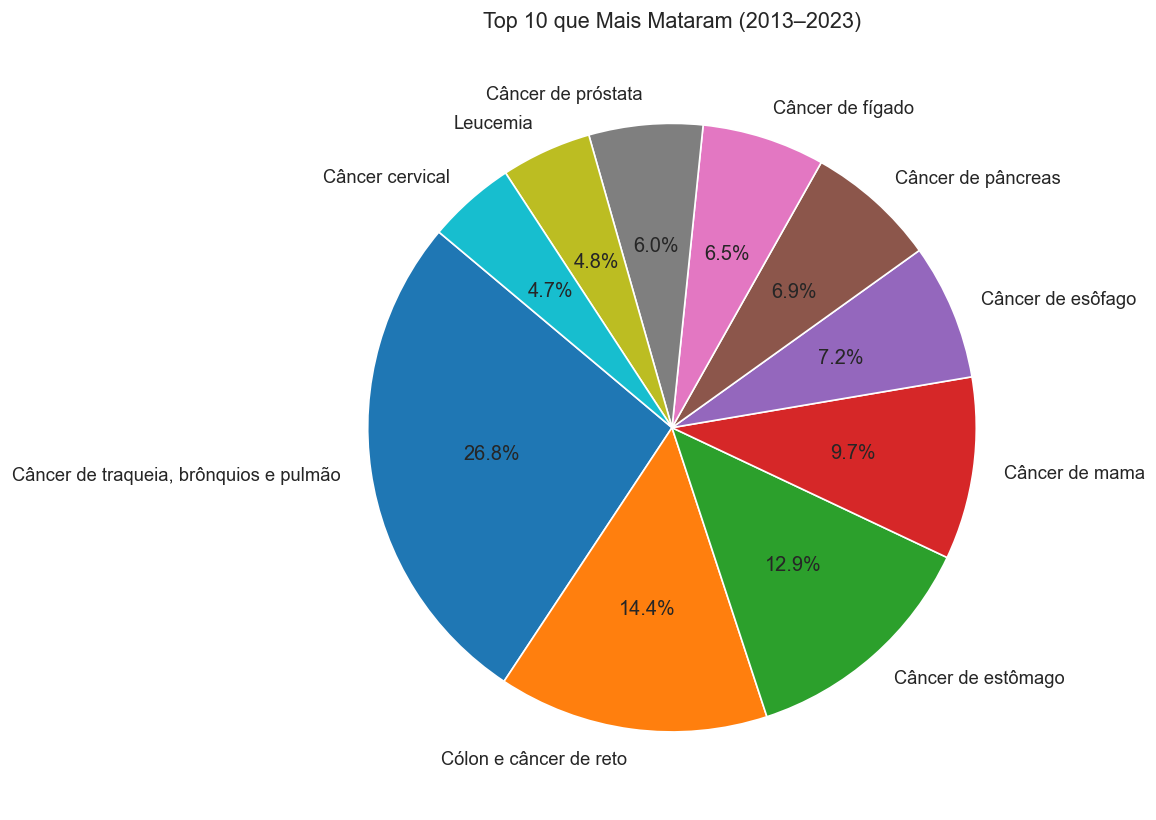

In [ ]:
print('=' * 55)
print('     CÂNCERES QUE MAIS E MENOS MATARAM')
print('=' * 55)

print('\n🎯 O QUE DESEJA VER:')
print('  1 — Top 10 que mais mataram')
print('  2 — Top 10 que menos mataram')
print('  3 — Ambos')
ordem = pedir_opcao('\nEscolha (1-3): ', 1, 3)  # valida a escolha entre 1 e 3

print('\n📅 PERÍODO:')
ano_inicio, ano_fim = pedir_periodo()  # pede e valida o período

print('\n📊 TIPO DE GRÁFICO:')
print('  ⚠️  Gráfico de linha não se aplica aqui pois')
print('      esta análise compara tipos e não evolução no tempo')
print()
print('  1 — Barra horizontal (recomendado)')
print('  2 — Barra vertical')
print('  3 — Pizza')
tipo_grafico = pedir_opcao('\nEscolha o tipo (1-3): ', 1, 3)

# filtra óbitos no período e soma por tipo de câncer
df_mortes = df[
    (df['medida']  == 'Óbitos')    &  # apenas registros de óbito
    (df['metrica'] == 'Número')    &  # em número absoluto
    (df['ano']     >= ano_inicio)  &  # dentro do período
    (df['ano']     <= ano_fim)
].groupby('causa')['valor'].sum().sort_values()  # agrupa por causa e soma

top_mais  = df_mortes.nlargest(10)   # 10 cânceres que mais mataram
top_menos = df_mortes.nsmallest(10)  # 10 cânceres que menos mataram

# função auxiliar para plotar o gráfico conforme o tipo escolhido
def plot_cancer(ax, dados, titulo, cor):
    if tipo_grafico == 1:  # barra horizontal
        ax.barh(dados.index, dados.values, color=cor)
        ax.set_xlabel('Total de óbitos')
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_eixo))  # formata eixo X
        for i, v in enumerate(dados.values):
            label = f'{v/1e6:.2f}M' if v >= 1e6 else f'{v/1e3:.0f}K'
            ax.text(v, i, f' {label}', va='center', fontsize=8)  # rótulo ao lado da barra
    elif tipo_grafico == 2:  # barra vertical
        ax.bar(dados.index, dados.values, color=cor)
        ax.set_xticklabels(dados.index, rotation=45, ha='right', fontsize=8)
        ax.set_ylabel('Total de óbitos')
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_eixo))
    elif tipo_grafico == 3:  # pizza
        ax.pie(dados.values, labels=dados.index, autopct='%1.1f%%', startangle=140)
        ax.set_ylabel('')
    ax.set_title(titulo, fontsize=13, pad=12)

# gera o(s) gráfico(s) conforme a escolha do usuário
if ordem == 3:  # ambos lado a lado
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))
    plot_cancer(ax1, top_menos, f'Top 10 que Menos Mataram ({ano_inicio}–{ano_fim})', 'steelblue')
    plot_cancer(ax2, top_mais,  f'Top 10 que Mais Mataram ({ano_inicio}–{ano_fim})',  'crimson')
elif ordem == 1:  # só os que mais mataram
    fig, ax1 = plt.subplots(figsize=(13, 7))
    plot_cancer(ax1, top_mais,  f'Top 10 que Mais Mataram ({ano_inicio}–{ano_fim})',  'crimson')
else:             # só os que menos mataram
    fig, ax1 = plt.subplots(figsize=(13, 7))
    plot_cancer(ax1, top_menos, f'Top 10 que Menos Mataram ({ano_inicio}–{ano_fim})', 'steelblue')

plt.tight_layout()
plt.show()


### Célula 13 — Incidência vs Mortalidade: Taxa de Letalidade

Vimos quantos adoecem e quantos morrem separadamente. Agora combinamos as duas informações para calcular a **taxa de letalidade**: a proporção de doentes que vêm a óbito.

Um câncer com alta incidência e alta letalidade (como pâncreas) é duplamente preocupante. Já um com alta incidência e baixa letalidade (como tireoide) indica bom prognóstico ou diagnóstico precoce.

    INCIDÊNCIA vs MORTALIDADE — LETALIDADE

📅 PERÍODO:

🔢 QUANTOS TIPOS EXIBIR (Top N por incidência):


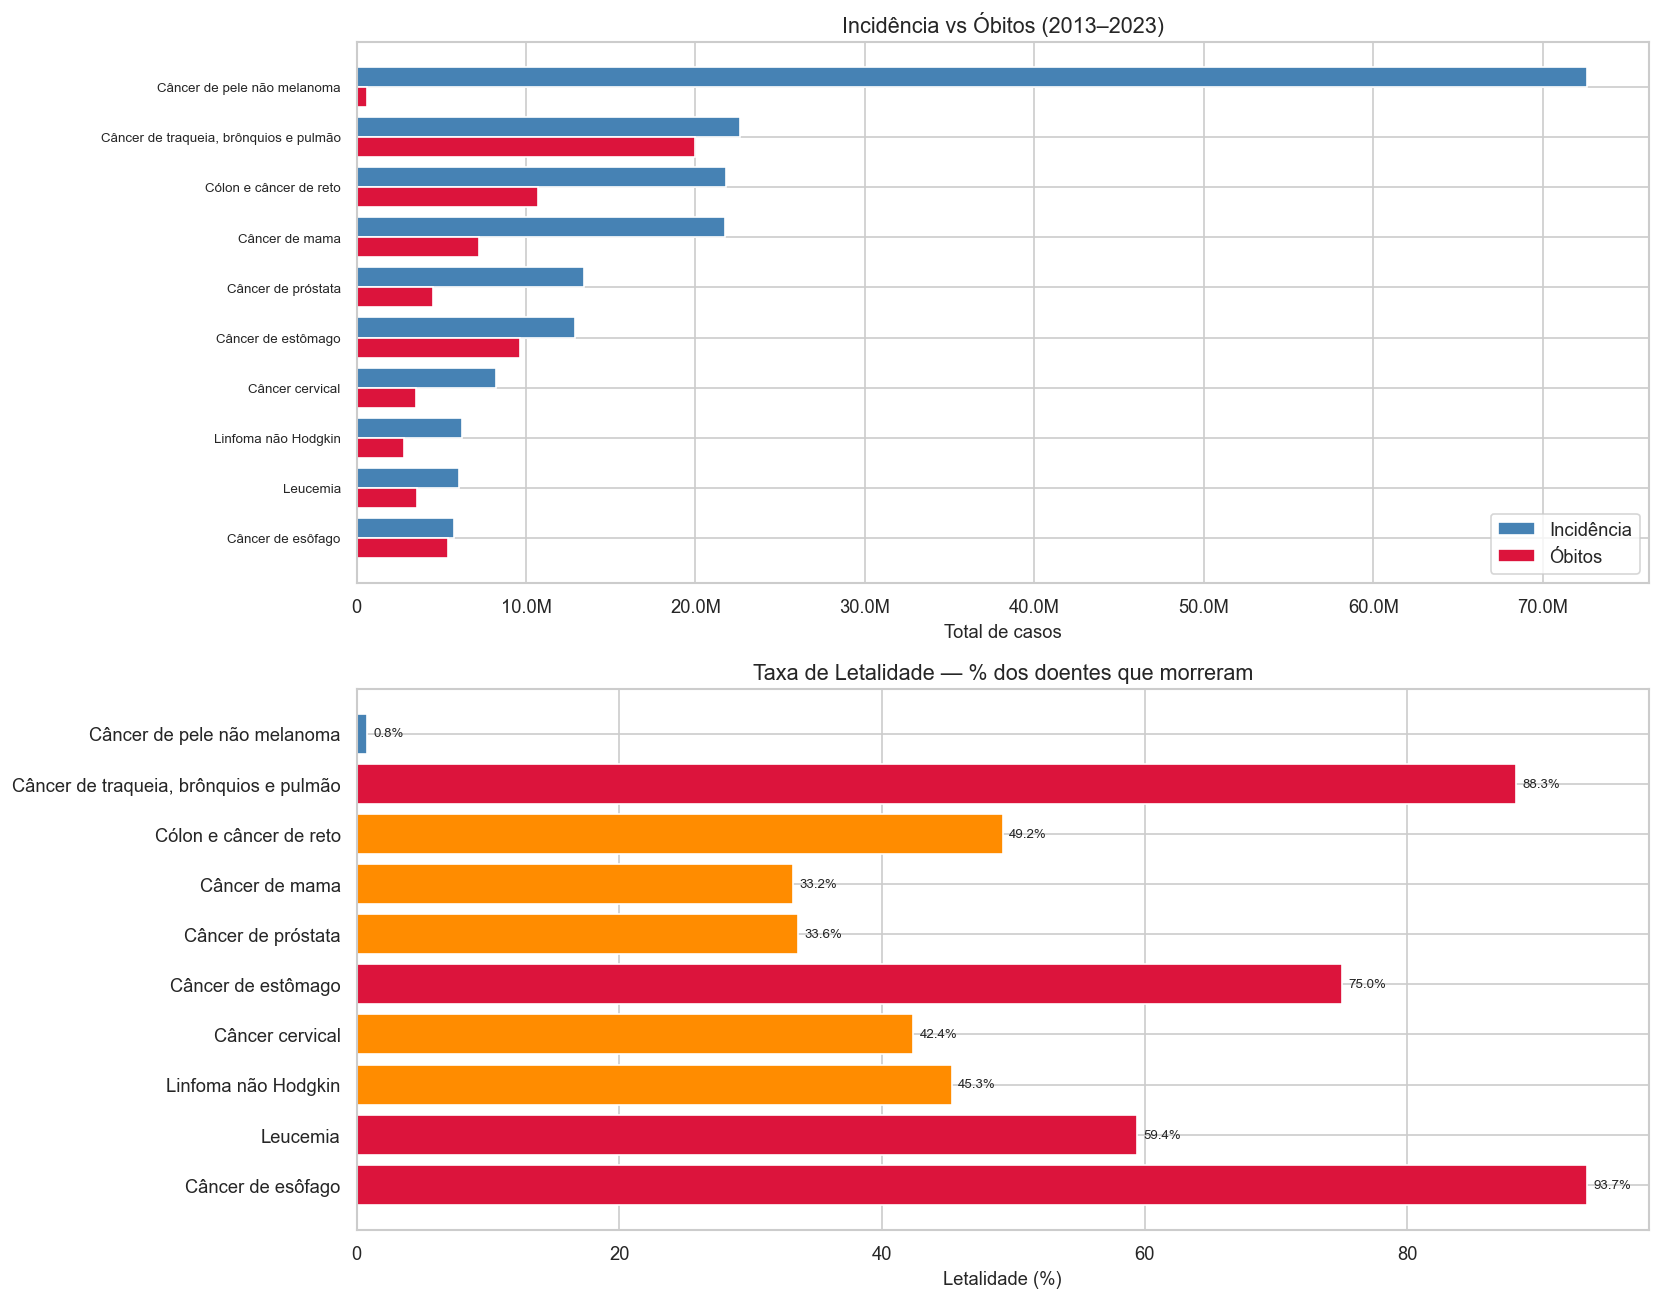


📋 TABELA RESUMO:
                                        incidencia     obitos  letalidade
causa                                                                    
Câncer de esôfago                        5,751,669  5,386,751          94
Leucemia                                 6,032,057  3,582,419          59
Linfoma não Hodgkin                      6,223,847  2,821,145          45
Câncer cervical                          8,218,320  3,488,042          42
Câncer de estômago                      12,866,878  9,644,406          75
Câncer de próstata                      13,400,875  4,506,378          34
Câncer de mama                          21,753,023  7,228,789          33
Cólon e câncer de reto                  21,778,783 10,707,346          49
Câncer de traqueia, brônquios e pulmão  22,638,348 19,991,223          88
Câncer de pele não melanoma             72,629,150    597,489           1


In [ ]:
print('=' * 55)
print('    INCIDÊNCIA vs MORTALIDADE — LETALIDADE')
print('=' * 55)

print('\n📅 PERÍODO:')
ano_inicio, ano_fim = pedir_periodo()  # pede e valida o período

print('\n🔢 QUANTOS TIPOS EXIBIR (Top N por incidência):')
top_n = pedir_top_n('  Número (ex: 10, 15): ')  # pede e valida o número de cânceres

# soma a incidência por causa no período selecionado
inc = df[
    (df['medida']  == 'Incidência') &
    (df['metrica'] == 'Número')     &
    (df['ano'].between(ano_inicio, ano_fim))   # filtra o intervalo de anos
].groupby('causa')['valor'].sum()             # soma por tipo de câncer

# soma os óbitos por causa no mesmo período
obt = df[
    (df['medida']  == 'Óbitos')  &
    (df['metrica'] == 'Número')  &
    (df['ano'].between(ano_inicio, ano_fim))
].groupby('causa')['valor'].sum()

# junta incidência e óbitos em uma única tabela; dropna remove causas sem os dois dados
comp = pd.DataFrame({'incidencia': inc, 'obitos': obt}).dropna()

# calcula a taxa de letalidade: % dos doentes que morreram
comp['letalidade'] = (comp['obitos'] / comp['incidencia'] * 100).round(1)

# seleciona os N cânceres com maior incidência e ordena para o gráfico
comp = comp.nlargest(top_n, 'incidencia').sort_values('incidencia')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 11))  # dois gráficos empilhados

# ── Subplot 1: barras lado a lado (incidência vs óbitos) ──
largura = 0.4                          # largura de cada barra
y = range(len(comp))                   # posições no eixo Y
ax1.barh([i + largura/2 for i in y], comp['incidencia'],   # barras de incidência
         height=largura, label='Incidência', color='steelblue')
ax1.barh([i - largura/2 for i in y], comp['obitos'],       # barras de óbitos
         height=largura, label='Óbitos', color='crimson')
ax1.set_yticks(list(y))
ax1.set_yticklabels(comp.index, fontsize=8)                # nomes dos cânceres
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_eixo))
ax1.set_xlabel('Total de casos')
ax1.set_title(f'Incidência vs Óbitos ({ano_inicio}–{ano_fim})', fontsize=13)
ax1.legend()

# ── Subplot 2: taxa de letalidade por cor ──
# azul = baixa letalidade (<20%), laranja = média (20-50%), vermelho = alta (>50%)
cores = ['crimson' if v >= 50 else 'darkorange' if v >= 20 else 'steelblue'
         for v in comp['letalidade']]
bars = ax2.barh(comp.index, comp['letalidade'], color=cores)
for bar, val in zip(bars, comp['letalidade']):
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
             f'{val:.1f}%', va='center', fontsize=8)  # rótulo com o percentual
ax2.set_xlabel('Letalidade (%)')
ax2.set_title('Taxa de Letalidade — % dos doentes que morreram', fontsize=13)

plt.tight_layout()
plt.show()

print('\n📋 TABELA RESUMO:')
print(comp[['incidencia', 'obitos', 'letalidade']].to_string())  # exibe tabela completa


### Célula 14 — Prevalência: Quantas Pessoas Vivem com Câncer?

Diferente da incidência (casos *novos* por ano), a prevalência mede o total de pessoas que **convivem com o diagnóstico** em determinado momento — incluindo sobreviventes e pacientes em tratamento.

Uma prevalência crescente pode indicar tanto aumento de casos quanto melhora na sobrevida (mais pessoas vivendo mais tempo com a doença).

      PREVALÊNCIA — VIVENDO COM CÂNCER
ℹ️  Prevalência = total de pessoas que têm ou tiveram
   câncer (inclui novos casos + sobreviventes).


📊 TIPO DE GRÁFICO:
  1 — Linha  (evolução por tipo ao longo do tempo)
  2 — Área   (volume empilhado)
  3 — Barra horizontal (total acumulado por tipo)

📅 PERÍODO:

🎗️  TIPOS DE CÂNCER DISPONÍVEIS:
   1 — Câncer cervical
   2 — Câncer da vesícula biliar e das vias biliares
   3 — Câncer de Laringe
   4 — Câncer de bexiga
   5 — Câncer de estômago
   6 — Câncer de esôfago
   7 — Câncer de fígado
   8 — Câncer de lábio e cavidade oral
   9 — Câncer de mama
  10 — Câncer de nasofaringe
  11 — Câncer de ovário
  12 — Câncer de pele não melanoma
  13 — Câncer de próstata
  14 — Câncer de pâncreas
  15 — Câncer de testículo
  16 — Câncer de tireoide
  17 — Câncer de traqueia, brônquios e pulmão
  18 — Câncer de útero
  19 — Câncer ocular
  20 — Câncer renal
  21 — Cólon e câncer de reto
  22 — Leucemia
  23 — Linfoma de Hodgkin
  24 — Linfoma não Hodg

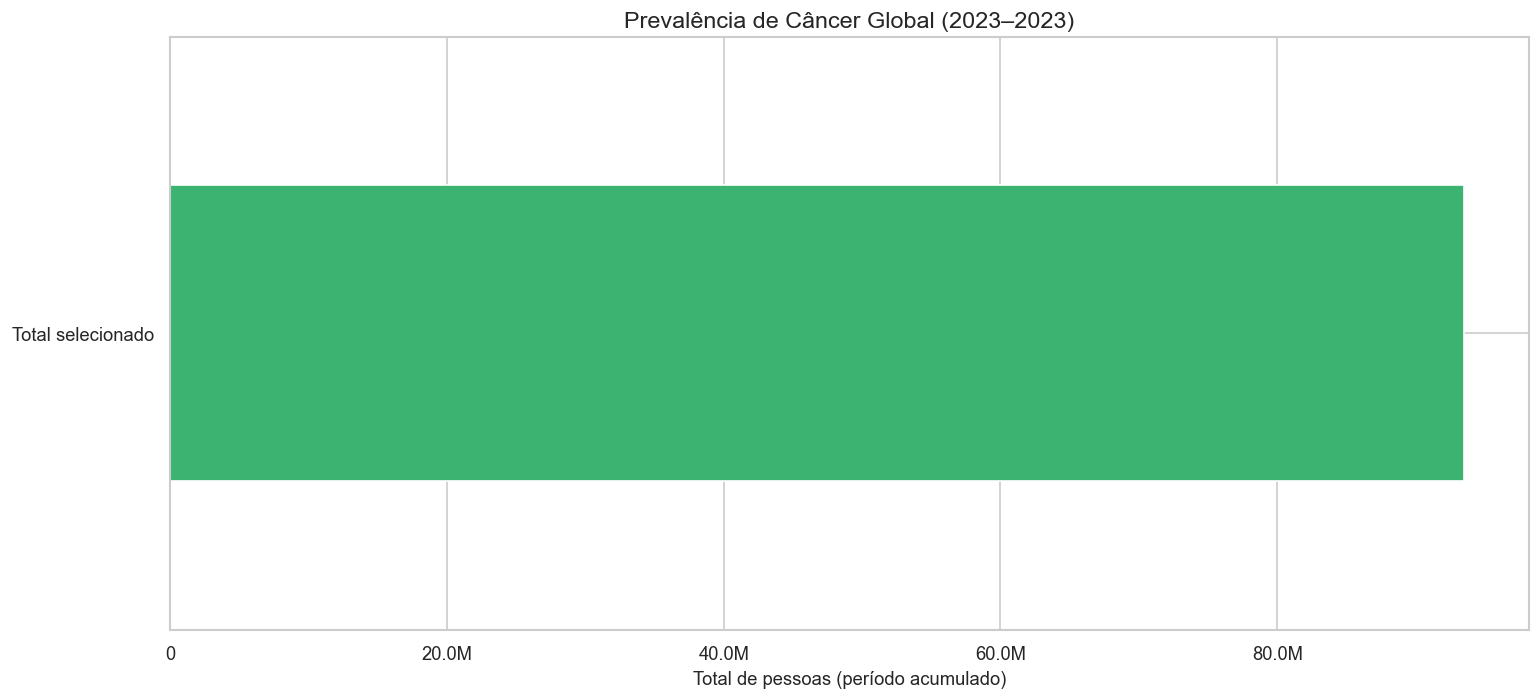


✅ Modo: somado | 32 tipo(s) selecionado(s)


In [ ]:
print('=' * 55)
print('      PREVALÊNCIA — VIVENDO COM CÂNCER')
print('=' * 55)
print('ℹ️  Prevalência = total de pessoas que têm ou tiveram')
print('   câncer (inclui novos casos + sobreviventes).')
print()

print('\n📊 TIPO DE GRÁFICO:')
print('  1 — Linha  (evolução por tipo ao longo do tempo)')
print('  2 — Área   (volume empilhado)')
print('  3 — Barra horizontal (total acumulado por tipo)')
tipo_grafico = pedir_opcao('\nEscolha (1-3): ', 1, 3)  # valida a escolha

print('\n📅 PERÍODO:')
ano_inicio, ano_fim = pedir_periodo()  # pede e valida o período

# lista de cânceres com dados de prevalência disponíveis
tipos_prev = sorted(df[df['medida'] == 'Prevalência']['causa'].unique())

print('\n🎗️  TIPOS DE CÂNCER DISPONÍVEIS:')
for i, t in enumerate(tipos_prev, 1):  # exibe lista numerada
    print(f'  {i:2} — {t}')
print('   0 — Todos (somado)')

# pede e valida a seleção de cânceres
causas_sel = pedir_causas(tipos_prev, '\nEscolha os tipos (ex: 1,3,5 ou 0 para todos): ')

# filtra o banco para prevalência no período e cânceres selecionados
df_prev = df[
    (df['medida']  == 'Prevalência') &  # apenas registros de prevalência
    (df['metrica'] == 'Número')      &  # em número absoluto
    (df['ano'].between(ano_inicio, ano_fim)) &
    (df['causa'].isin(causas_sel))
].copy()

# se 5 ou menos tipos: exibe cada um separado; se mais: soma em uma série única
if len(causas_sel) <= 5:
    df_pivot = df_prev.pivot_table(index='ano', columns='causa', values='valor')
    modo = 'separado'
else:
    df_pivot = df_prev.groupby('ano')['valor'].sum().to_frame('Total selecionado')
    modo = 'somado'

fig, ax = plt.subplots(figsize=(13, 6))

if tipo_grafico == 1:  # gráfico de linha com marcadores
    for col in df_pivot.columns:
        ax.plot(df_pivot.index, df_pivot[col], marker='o', linewidth=2.5, label=col)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_eixo))
    ax.set_ylabel('Pessoas vivendo com câncer')
    ax.set_xlabel('Ano')
    ax.legend(loc='upper left', fontsize=8, bbox_to_anchor=(1, 1))
elif tipo_grafico == 2:  # área empilhada
    df_pivot.plot(kind='area', ax=ax, alpha=0.5, stacked=True)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_eixo))
    ax.set_ylabel('Pessoas vivendo com câncer')
    ax.set_xlabel('Ano')
    ax.legend(loc='upper left', fontsize=8, bbox_to_anchor=(1, 1))
elif tipo_grafico == 3:  # barra horizontal com total acumulado
    df_pivot.sum().sort_values().plot(kind='barh', ax=ax, color='mediumseagreen')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_eixo))
    ax.set_xlabel('Total de pessoas (período acumulado)')

ax.set_title(f'Prevalência de Câncer Global ({ano_inicio}–{ano_fim})', fontsize=14)
plt.tight_layout()
plt.show()

print(f'\n✅ Modo: {modo} | {len(causas_sel)} tipo(s) selecionado(s)')


## Bloco 3 — Análise Avançada

Com a base descritiva estabelecida, aprofundamos a análise em duas direções:
- **Perfil de agressividade**: comparar quem adoece vs quem morre revela se um câncer é curável ou agressivo
- **Evolução temporal**: identificar quais cânceres estão crescendo mais rápido ao longo da década

### Célula 15 — Perfil dos Cânceres: Incidência vs Mortalidade

Este gráfico de dispersão é o mais analítico do estudo. Cada ponto é um tipo de câncer posicionado pelo volume de casos (eixo X) e óbitos (eixo Y). A cor indica a letalidade.

- **Quadrante superior direito** → câncer *comum e agressivo* (ex: pulmão, fígado)
- **Quadrante inferior direito** → câncer *comum e curável* (ex: tireoide, mama)

As linhas tracejadas representam a mediana, dividindo os cânceres em quatro perfis distintos.

  PERFIL DO CÂNCER: INCIDÊNCIA vs MORTALIDADE
ℹ️  Cada ponto = 1 tipo de câncer
   Eixo X   = quantas pessoas adoecem
   Eixo Y   = quantas morrem
   Cor      = % de letalidade (verde=baixa / vermelho=alta)

   Direita/baixo → comum e CURÁVEL   (ex: tireoide)
   Direita/cima  → comum e AGRESSIVO (ex: pulmão)


📅 PERÍODO:

🔢 QUANTOS CÂNCERES EXIBIR (Top N por incidência):


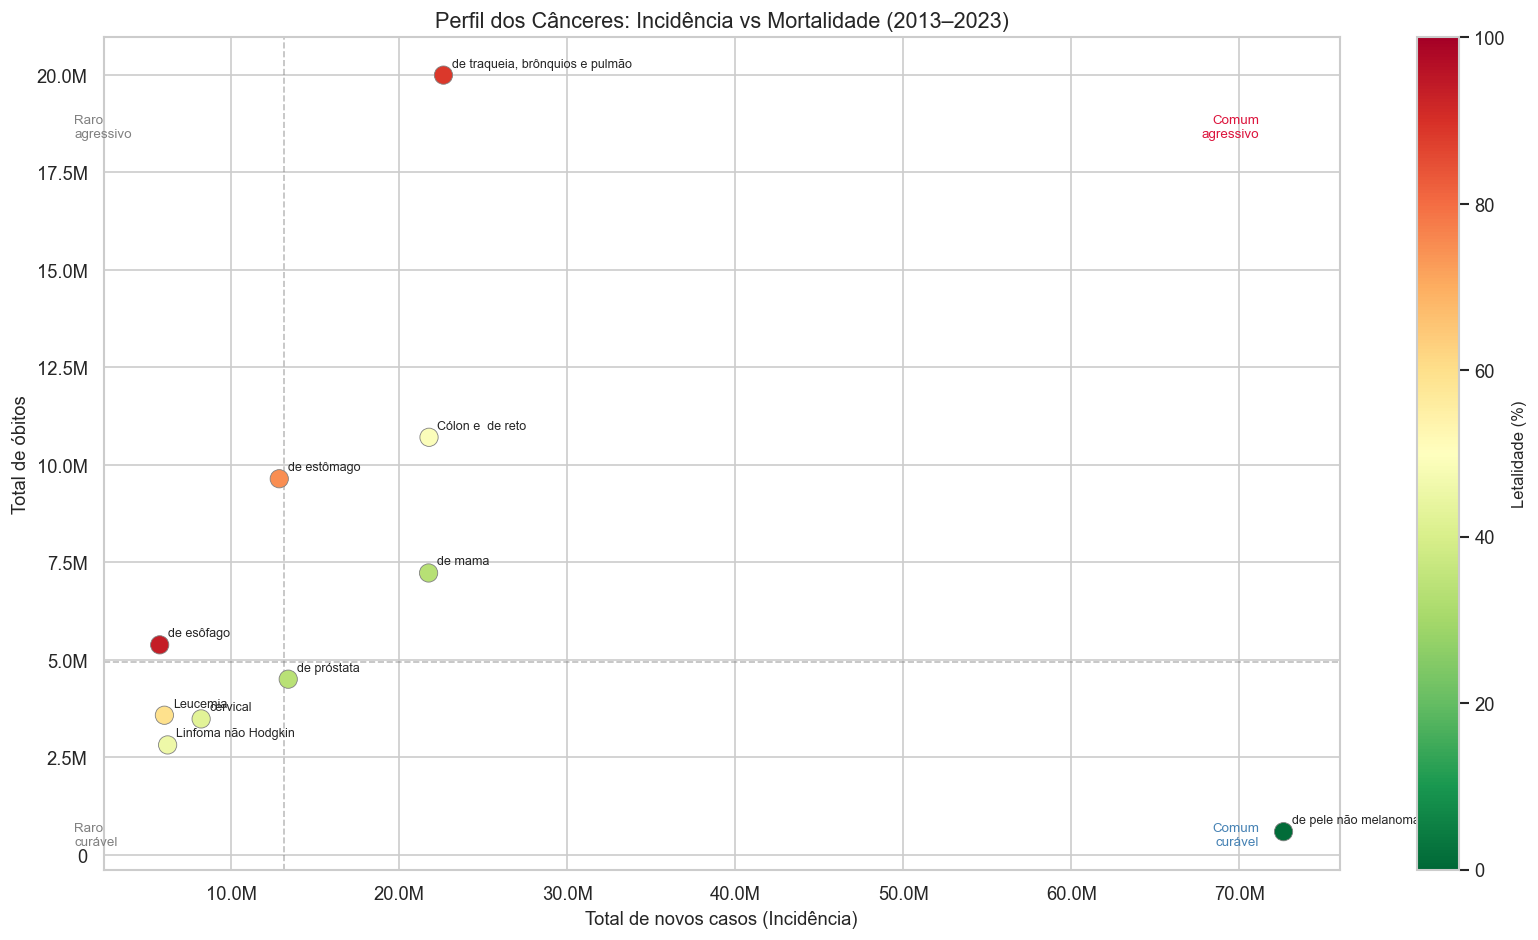

In [ ]:
print('=' * 55)
print('  PERFIL DO CÂNCER: INCIDÊNCIA vs MORTALIDADE')
print('=' * 55)
print('ℹ️  Cada ponto = 1 tipo de câncer')
print('   Eixo X   = quantas pessoas adoecem')
print('   Eixo Y   = quantas morrem')
print('   Cor      = % de letalidade (verde=baixa / vermelho=alta)')
print()
print('   Direita/baixo → comum e CURÁVEL   (ex: tireoide)')
print('   Direita/cima  → comum e AGRESSIVO (ex: pulmão)')
print()

print('\n📅 PERÍODO:')
ano_inicio, ano_fim = pedir_periodo()  # pede e valida o período

print('\n🔢 QUANTOS CÂNCERES EXIBIR (Top N por incidência):')
top_n = pedir_top_n('  Número (ex: 15, 20): ', minimo=1, maximo=40)

# soma incidência por causa no período
inc = df[
    (df['medida']  == 'Incidência') &
    (df['metrica'] == 'Número')     &
    (df['ano'].between(ano_inicio, ano_fim))
].groupby('causa')['valor'].sum()

# soma óbitos por causa no mesmo período
obt = df[
    (df['medida']  == 'Óbitos')  &
    (df['metrica'] == 'Número')  &
    (df['ano'].between(ano_inicio, ano_fim))
].groupby('causa')['valor'].sum()

# junta os dois e calcula a letalidade
comp = pd.DataFrame({'incidencia': inc, 'obitos': obt}).dropna()
comp['letalidade'] = comp['obitos'] / comp['incidencia'] * 100  # % de mortalidade
comp = comp.nlargest(top_n, 'incidencia')  # mantém os N de maior incidência

# calcula as medianas para dividir o gráfico em quadrantes
med_inc = comp['incidencia'].median()
med_obt = comp['obitos'].median()

fig, ax = plt.subplots(figsize=(14, 8))

# gráfico de dispersão: posição = incidência/óbitos, cor = letalidade
scatter = ax.scatter(
    comp['incidencia'], comp['obitos'],
    s=120,                       # tamanho dos pontos
    c=comp['letalidade'],        # cor baseada na letalidade
    cmap='RdYlGn_r',             # verde (baixa) → vermelho (alta)
    vmin=0, vmax=100,            # escala de 0% a 100%
    edgecolors='gray', linewidth=0.5, zorder=3
)

# linhas tracejadas nas medianas para criar os quadrantes
ax.axvline(med_inc, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.axhline(med_obt, color='gray', linestyle='--', linewidth=1, alpha=0.5)

# rótulos dos quatro quadrantes
xmax = comp['incidencia'].max()
ymax = comp['obitos'].max()
ax.text(med_inc * 0.05, ymax * 0.95, 'Raro\nagressivo',
        fontsize=8, color='gray', va='top')
ax.text(xmax * 0.98,   ymax * 0.95, 'Comum\nagressivo',
        fontsize=8, color='crimson', va='top', ha='right')
ax.text(xmax * 0.98,   med_obt * 0.05, 'Comum\ncurável',
        fontsize=8, color='steelblue', ha='right')
ax.text(med_inc * 0.05, med_obt * 0.05, 'Raro\ncurável',
        fontsize=8, color='gray')

# anota cada ponto com o nome do câncer (remove a palavra 'câncer' para economizar espaço)
for causa, row in comp.iterrows():
    nome = causa.replace('Câncer', '').replace('câncer', '').strip()
    ax.annotate(nome, xy=(row['incidencia'], row['obitos']),
                xytext=(5, 5), textcoords='offset points', fontsize=7.5)

cbar = plt.colorbar(scatter, ax=ax)   # barra de cor lateral
cbar.set_label('Letalidade (%)', fontsize=10)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_eixo))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_eixo))
ax.set_xlabel('Total de novos casos (Incidência)', fontsize=11)
ax.set_ylabel('Total de óbitos', fontsize=11)
ax.set_title(
    f'Perfil dos Cânceres: Incidência vs Mortalidade ({ano_inicio}–{ano_fim})',
    fontsize=13
)
plt.tight_layout()
plt.show()


### Célula 16 — Evolução Percentual (2013 → 2023)

Analisamos o ritmo de crescimento de cada câncer na última década. É importante notar que **cânceres com alto volume absoluto** (como pulmão) tendem a aparecer com menor percentual de crescimento — não porque estejam diminuindo, mas porque sua base já era muito alta em 2013.

Esta visualização responde: *quais cânceres estão acelerando mais rápido?*

     EVOLUÇÃO PERCENTUAL — 2013 → 2023
ℹ️  Compara o valor de 2013 com o de 2023 e mostra
   quanto cada câncer cresceu (+) ou diminuiu (-) em %.

⚠️  Cânceres com alto volume absoluto (ex: pulmão) tendem a
   aparecer com menor % mesmo sendo os mais letais.
   Para ver quem mais mata em absoluto, use a Célula 13.


📊 QUAL MEDIDA ANALISAR:
  1 — Incidência (casos novos)
  2 — Óbitos

📊 ORDENAR POR:
  1 — Maior crescimento
  2 — Maior queda
  3 — Ambos (top 10 de cada)

🔢 QUANTOS CÂNCERES EXIBIR (ignorado se escolher Ambos):


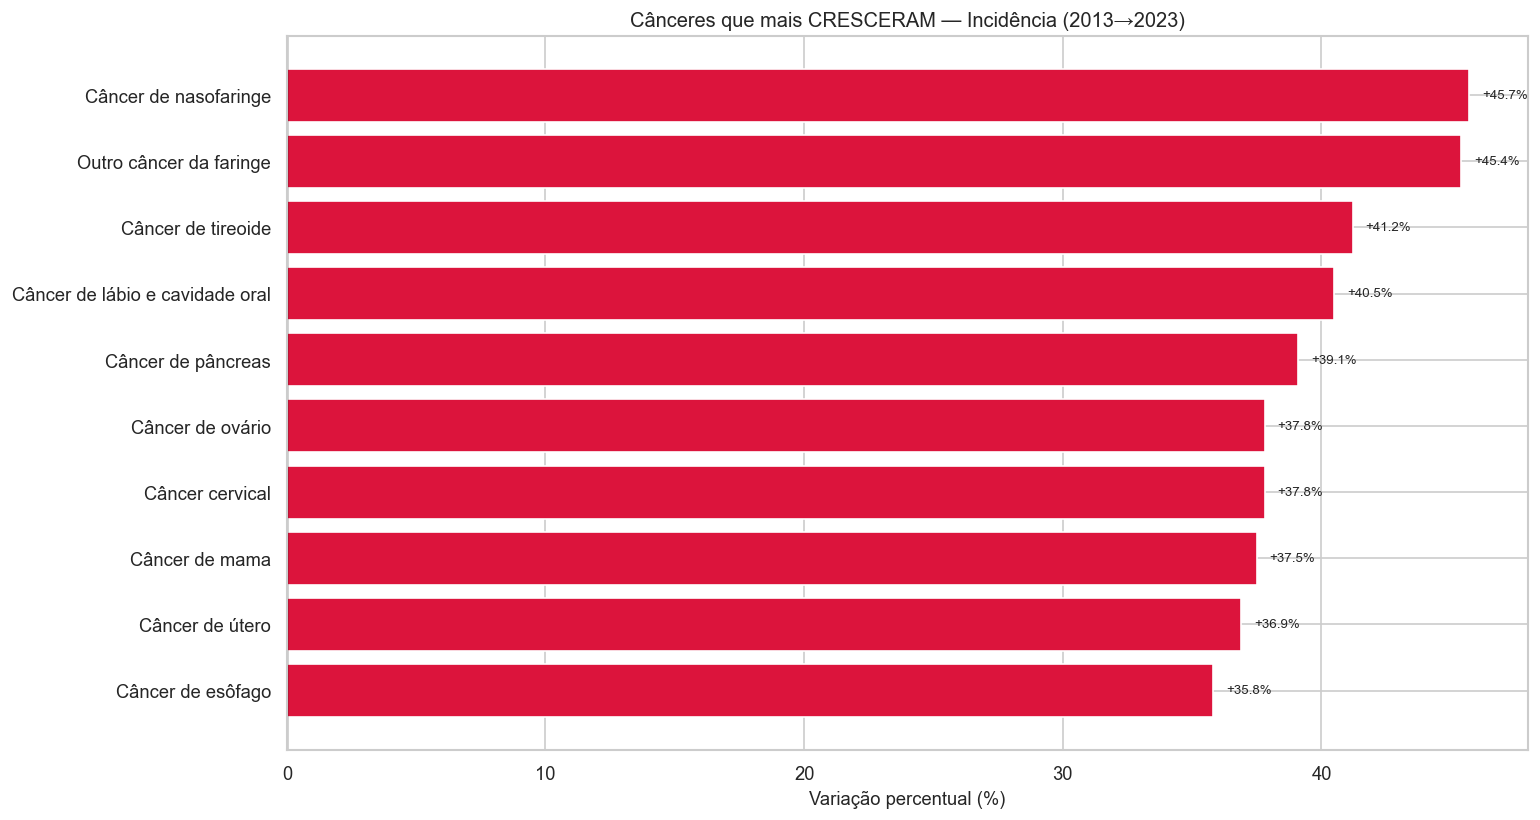


✅ Medida  : Incidência
   Período : 2013 → 2023
   Cânceres: 32 na base


In [ ]:
print('=' * 55)
print('     EVOLUÇÃO PERCENTUAL — 2013 → 2023')
print('=' * 55)
print('ℹ️  Compara o valor de 2013 com o de 2023 e mostra')
print('   quanto cada câncer cresceu (+) ou diminuiu (-) em %.')
print()
print('⚠️  Cânceres com alto volume absoluto (ex: pulmão) tendem a')
print('   aparecer com menor % mesmo sendo os mais letais.')
print('   Para ver quem mais mata em absoluto, use a Célula 13.')
print()

print('\n📊 QUAL MEDIDA ANALISAR:')
print('  1 — Incidência (casos novos)')
print('  2 — Óbitos')
opcao = pedir_opcao('\nEscolha (1-2): ', 1, 2)                   # valida a escolha entre 1 e 2
medida_sel = {1: 'Incidência', 2: 'Óbitos'}[opcao]               # converte número para nome

print('\n📊 ORDENAR POR:')
print('  1 — Maior crescimento')
print('  2 — Maior queda')
print('  3 — Ambos (top 10 de cada)')
ordem = pedir_opcao('\nEscolha (1-3): ', 1, 3)  # valida a escolha

print('\n🔢 QUANTOS CÂNCERES EXIBIR (ignorado se escolher Ambos):')
top_n = pedir_top_n('  Número (ex: 10, 15): ')  # pede e valida o número

# valor de cada causa no ano de 2013
v2013 = df[
    (df['medida']  == medida_sel) &  # medida escolhida pelo usuário
    (df['metrica'] == 'Número')   &  # em número absoluto
    (df['ano']     == 2013)          # apenas 2013
].groupby('causa')['valor'].sum()

# valor de cada causa no ano de 2023
v2023 = df[
    (df['medida']  == medida_sel) &
    (df['metrica'] == 'Número')   &
    (df['ano']     == 2023)
].groupby('causa')['valor'].sum()

# junta os dois anos em uma tabela e calcula a variação percentual
evol = pd.DataFrame({'v2013': v2013, 'v2023': v2023}).dropna()
evol['variacao_pct'] = ((evol['v2023'] - evol['v2013']) / evol['v2013'] * 100).round(1)

# função auxiliar para plotar o gráfico de evolução percentual
def plot_evolucao(ax, dados, titulo):
    # vermelho para crescimento, azul para queda
    cores = ['crimson' if v >= 0 else 'steelblue' for v in dados['variacao_pct']]
    bars = ax.barh(dados.index, dados['variacao_pct'], color=cores)
    ax.axvline(0, color='black', linewidth=0.8)  # linha vertical no zero
    for bar, val in zip(bars, dados['variacao_pct']):
        pos   = bar.get_width()
        ha    = 'left' if pos >= 0 else 'right'   # alinha o rótulo pelo sinal
        shift = 0.5 if pos >= 0 else -0.5          # desloca levemente o rótulo
        ax.text(pos + shift, bar.get_y() + bar.get_height() / 2,
                f'{val:+.1f}%', va='center', ha=ha, fontsize=8)
    ax.set_xlabel('Variação percentual (%)')
    ax.set_title(titulo, fontsize=12)

# gera o(s) gráfico(s) conforme a escolha
if ordem == 3:  # ambos lado a lado
    cresceu = evol.nlargest(10, 'variacao_pct').sort_values('variacao_pct')
    caiu    = evol.nsmallest(10, 'variacao_pct').sort_values('variacao_pct', ascending=False)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))
    plot_evolucao(ax1, cresceu, f'Top 10 que mais CRESCERAM\n{medida_sel} (2013→2023)')
    plot_evolucao(ax2, caiu,   f'Top 10 que mais DIMINUÍRAM\n{medida_sel} (2013→2023)')
elif ordem == 1:  # só os que mais cresceram
    dados = evol.nlargest(top_n, 'variacao_pct').sort_values('variacao_pct')
    fig, ax = plt.subplots(figsize=(13, 7))
    plot_evolucao(ax, dados, f'Cânceres que mais CRESCERAM — {medida_sel} (2013→2023)')
else:             # só os que mais diminuíram (ordem == 2)
    dados = evol.nsmallest(top_n, 'variacao_pct').sort_values('variacao_pct', ascending=False)
    fig, ax = plt.subplots(figsize=(13, 7))
    plot_evolucao(ax, dados, f'Cânceres que mais DIMINUÍRAM — {medida_sel} (2013→2023)')

plt.tight_layout()
plt.show()

print(f'\n✅ Medida  : {medida_sel}')
print(f'   Período : 2013 → 2023')
print(f'   Cânceres: {len(evol)} na base')


## Conclusão

### O que os dados revelam sobre o câncer global (2013–2023)?

A análise do banco GBD 2023 permite responder à pergunta central deste estudo sob diferentes ângulos:

---

**1. Incidência — Quem mais adoece**
Os cânceres de pulmão, mama, cólon e próstata lideram em número de casos novos globalmente. A incidência cresceu na maioria dos tipos ao longo da década, reflexo do envelhecimento populacional e de fatores comportamentais.

---

**2. Mortalidade — Quem mais mata**
O câncer de pulmão se destaca como o mais letal em números absolutos, seguido por fígado e estômago. Cânceres com alta mortalidade e alta incidência representam o maior desafio para os sistemas de saúde.

---

**3. Letalidade — Quem é mais agressivo**
O gráfico de dispersão (Célula 16) evidencia dois perfis opostos:
- **Cânceres curáveis** (tireoide, mama): alta incidência, baixa mortalidade
- **Cânceres agressivos** (pâncreas, fígado): qualquer incidência com alta mortalidade

---

**4. Evolução percentual — Quem está crescendo mais rápido**
Cânceres com menor volume absoluto em 2013 tendem a apresentar maior crescimento percentual. Isso não os torna mais preocupantes que o pulmão em termos absolutos, mas indica onde a tendência de crescimento é mais acelerada.

---

### Limitação importante
Os dados são de nível global e agregam populações muito distintas. Tendências mundiais podem não refletir a realidade brasileira ou regional. Para conclusões locais, seria necessário filtrar por país ou região.

---

*Análise produzida com dados do Global Burden of Disease Study 2023 — IHME, Seattle.*
